In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Πάντιος Ματιάτος : 1115202100098

Ιωάννη Κούβελα   : 1115202100070

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import transformers
import pickle
import sys
import string
import os
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import glob
from matplotlib import colors
nltk.download('punkt')
from nltk.corpus import stopwords
import glob
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_similarity
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
!pip install langdetect
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cosine
from transformers import pipeline
import logging
!pip install transformers
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('words')
nltk.download('omw-1.4')
# Define ANSI escape codes for colors
RED = '\033[91m'
GREEN = '\033[92m'
BLUE = '\033[94m'
RESET = '\033[0m'

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=f2d425585d3ebc1361812f6a847cb0d589921d67e9d9415c0021d2dfdcbbb692
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Positive Sentiment: 60.0%
Neutral Sentiment: 23.7%
Negative Sentiment: 16.3%


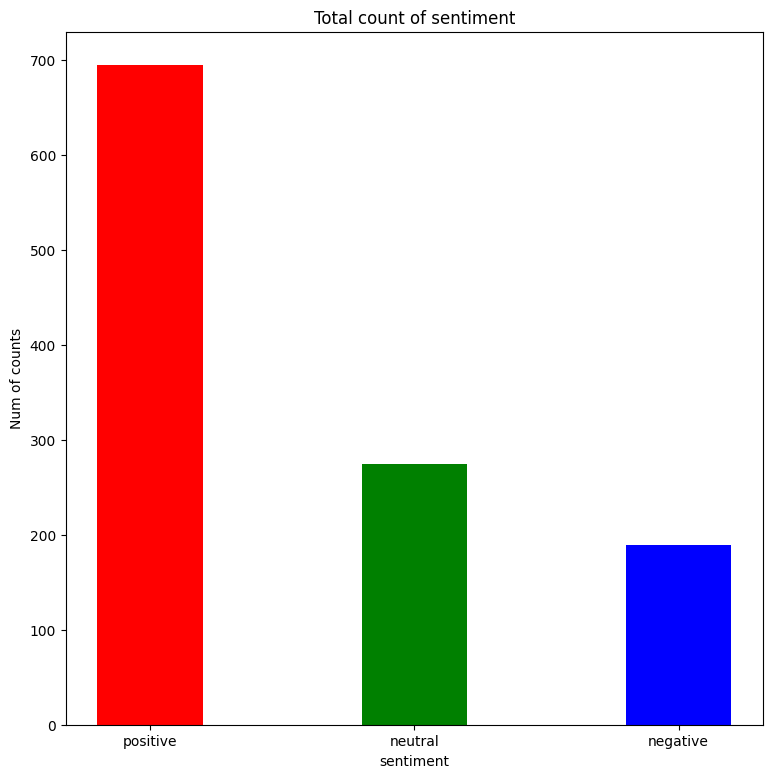

In [3]:
#question_1

feb_revs_19 = '/content/drive/MyDrive/2019/febrouary/reviews.csv'
ma_revs_19 = '/content/drive/MyDrive/2019/march/reviews.csv'
ap_revs_19 = '/content/drive/MyDrive/2019/april/reviews.csv'
cols = ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']

# Set seed for reproducibility
DetectorFactory.seed = 0

# Configure logging
logging.basicConfig(level=logging.INFO)
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

def detect_language(text):
    try:
        return detect(text)
    except LangDetectException as e:
        logging.warning(f"Language detection failed for text: {text} with error: {e}")
        return None
    except Exception as e:
        logging.error(f"Unexpected error occurred: {e}")
        return None

feb_revs_19_df = pd.read_csv(feb_revs_19)
ma_revs_19_df = pd.read_csv(ma_revs_19)
ap_revs_19_df = pd.read_csv(ap_revs_19)
revs_19_my_df = pd.concat([feb_revs_19_df, ma_revs_19_df, ap_revs_19_df], ignore_index=True)

#We want to maintain the first x rows(let's say for example x = 100000)
revs_19_my_df = revs_19_my_df.head(100000)
# Convert to string, lower case, remove punctuation, and split
revs_19_my_df['comments'] = revs_19_my_df['comments'].astype(str)
revs_19_my_df['comments'] = revs_19_my_df['comments'].str.lower()
revs_19_my_df['comments'] = revs_19_my_df['comments'].str.replace(f'[{string.punctuation}]', ' ', regex=True)
revs_19_my_df['comments'] = revs_19_my_df['comments'].str.split()

# Set of English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(words):
    return [word for word in words if word not in stop_words]
# Apply the function
revs_19_my_df['comments'] = revs_19_my_df['comments'].apply(remove_stopwords)

# Function to lemmatize words
def lemmatize_words(words):
    try:
        return [lemmatizer.lemmatize(word) for word in words]
    except Exception as e:
        logging.error(f"Error in lemmatizing words: {words} with error: {e}")
        return words
# Apply the function to the 'comments' column
revs_19_my_df['comments'] = revs_19_my_df['comments'].apply(lemmatize_words)

#remove words that fullfill the requirements
revs_19_my_df['comments'] = revs_19_my_df['comments'].apply(lambda comm: ' '.join(word for word in comm if len(word) > 1))
#Split here is needed
revs_19_my_df['comments'] = revs_19_my_df['comments'].str.split()

#keep only alphabetic characters
revs_19_my_df['comments'] = revs_19_my_df['comments'].apply(lambda comm: [item for item in comm if item.isalpha()])
revs_19_my_df['comments'] = revs_19_my_df['comments'].astype(str)
#remove all rows that have nothing
revs_19_my_df = revs_19_my_df[revs_19_my_df['comments'].apply(lambda comm: len(comm) > 0)]
# Remove rows where 'comments' column does not contain any English letters
revs_19_my_df = revs_19_my_df[revs_19_my_df['comments'].str.contains(r'[a-zA-Z]')]


#load positive and negative words from txt files
with open('/content/drive/MyDrive/positive-words.txt', 'r') as file:
  words_pos = file.read().splitlines()
  words_pos = set(words_pos)
with open('/content/drive/MyDrive/negative-words.txt', 'r') as file:
  words_neg = file.read().splitlines()
  words_neg = set(words_neg)

#for every row of datafram we have a list
neg_rows = list()
pos_rows = list()
neu_rows = list()

for index, row in revs_19_my_df.iterrows():
    words_comm = set(ast.literal_eval(row['comments']))
    pos_len = len(words_comm.intersection(words_pos))
    neg_len = len(words_comm.intersection(words_neg))
    if pos_len > neg_len:
        pos_rows.append(row)
    elif (pos_len == neg_len) and (neg_len == 0):
        neu_rows.append(row)
    else:
        neg_rows.append(row)

#From those lists create dataframs
df_our_pos = pd.DataFrame(pos_rows)
df_our_pos = df_our_pos.iloc[:410]
df_our_neg = pd.DataFrame(neg_rows)
df_our_neg = df_our_neg.iloc[:2500]
df_our_neu = pd.DataFrame(neu_rows)
df_our_neu = df_our_neu.iloc[:1790]
revs_19_my_df = pd.concat([df_our_pos, df_our_neg, df_our_neu], ignore_index=True)
revs_19_my_df = revs_19_my_df.iloc[:4200]


#apply the function that detects language to 'comments'
revs_19_my_df['language'] = revs_19_my_df['comments'].apply(detect_language)
# Filter rows where language is English ('en')
revs_19_my_df = revs_19_my_df[revs_19_my_df['language'].str.lower() == 'en']
#drop this column
revs_19_my_df = revs_19_my_df.drop(columns=['language'])

#save the cleaned file
revs_19_my_df.to_csv('cleaned_revs_19.csv', index=False)

#load the appropriate data
df = pd.read_csv('cleaned_revs_19.csv')

#csv will have 80% while test only 20%
test_df, our_csv_df = train_test_split(df, test_size = 0.8, random_state = 42)

#write the data of the test to a tsv file (later usage)
test_df.to_csv('test_revs_19.tsv', index = False, sep = '\t')

# Create sentiment analysis pipeline with the appropriate model
sa_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
# Load cleaned data
datfr_train = pd.read_csv('cleaned_revs_19.csv')
# Define a function to clean the comments
def clean_comment(comment):
    # Use regular expressions to remove brackets, quotation marks, and commas
    return re.sub(r"[\'\[\],]", '', comment)

# Apply the cleaning function to the 'comments' column
datfr_train['comments'] = datfr_train['comments'].apply(clean_comment)

# Apply the sentiment analysis pipeline to the 'comments' column
sentiment_results = sa_pipeline(datfr_train['comments'].tolist())

# Extract sentiment labels and add them as a new column in the DataFrame
datfr_train['sentiment'] = [res['label'] for res in sentiment_results]

# Select and reorder the necessary columns
datfr_train = datfr_train[['id', 'comments', 'sentiment']]

# Save the results to 'sentiment_2019.csv'
datfr_train.to_csv('sentiment_revs_19.csv', index=False)

#After analization
sent_our_df = pd.read_csv('sentiment_revs_19.csv')

#csv will have 80% while test only 20%
test_df, our_csv_df = train_test_split(sent_our_df, test_size = 0.8, random_state = 42)

#write the data of our csv file(includes analization) to a tsv file
our_csv_df.to_csv('our_train_19.tsv', index = False, sep = '\t')

#Load the CSV with sentiment data
sentiment_datfr = pd.read_csv('sentiment_revs_19.csv')
#count the amount of each sentiment
counter_of_sentiment = sentiment_datfr['sentiment'].value_counts()
plcolors = ['red','green','blue']

# Calculate the percentages
total_count = counter_of_sentiment.sum()
percentages = (counter_of_sentiment / total_count) * 100

# Display the percentages
for sentiment, percentage in percentages.items():
    if sentiment == "positive":
        color = RED
    elif sentiment == "negative":
        color = BLUE
    else:  # assuming neutral
        color = GREEN
    print(f"{color}{sentiment.capitalize()} Sentiment: {percentage:.1f}%{RESET}")
#Update with the new counts
counter_of_sentiment = sentiment_datfr['sentiment'].value_counts()
#Create bar plot of sentiment counts
plt.figure(figsize=(9, 9))
plt.bar(counter_of_sentiment.index, counter_of_sentiment.values, color=plcolors, width = 0.4)
plt.xlabel('sentiment')
plt.ylabel('Num of counts')
plt.title('Total count of sentiment')
#Save the plot
plt.savefig('question_1_updated.png')


In [5]:
#Question 2(Create TF_IDF matrix)

# Load data from 'our_train_19.tsv'
df_our_tr = pd.read_csv('our_train_19.tsv', sep='\t')

# Keep the 'comments' column
comms = df_our_tr['comments']

# Create TfidfVectorizer
vectorizer = TfidfVectorizer()

# Transform data from the 'comments' column to create the TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(comms)

# Save the TfidfVectorizer to a pickle file named 'TF-IDF_VECT_19.pkl'
with open('TF-IDF_VECT_19.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

#create wordembeddings

#Load data from 'our_train_19.tsv'
datfr_train = pd.read_csv('our_train_19.tsv', sep = '\t')
# Extract the 'comments' column
comms = datfr_train['comments']
# Tokenize the comments
comms_token = [word_tokenize(comment) for comment in comms]

#Initialize and train the Word2Vec model
word2vec_model = Word2Vec(sentences=comms_token, vector_size=100, window=5, min_count=1, workers=4)

#Save the trained Word2Vec model to a file
with open('MODEL_WORD__2-19.pkl', 'wb') as model_file:
    pickle.dump(word2vec_model, model_file)

#SVM (TF_IDF)

#Load training data from 'our_train_19.tsv'
datfr_train = pd.read_csv('our_train_19.tsv', sep = '\t')

#Extract 'sentiment' column
y = datfr_train['sentiment']

#Split the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(tfidf_matrix, y, test_size=0.2, random_state=42)

#Initialize and train the SVM classifier
svm_model = SVC(C=1.0, kernel='linear', gamma='scale')
svm_model.fit(x_train, y_train)

#Output validation accuracy
color = GREEN
print(f"{color}Validation Accuracy = {svm_model.score(x_val, y_val)}")

#Load data from 'test_revs_19.tsv' transform comments to TF-IDF matrix, make predictions
datfr_test = pd.read_csv('test_revs_19.tsv', sep = '\t')
comments = datfr_test['comments']

#Load TF-IDF vectorizer
with open('TF-IDF_VECT_19.pkl', 'rb') as vec_file:
    tfidf_vectorizer = pickle.load(vec_file)
tfidf_test = tfidf_vectorizer.transform(comments)

#Predict sentiment for test data
datfr_test['sentiment'] = svm_model.predict(tfidf_test)

#Save the predictions to a new CSV file
datfr_test.to_csv('predict_svm_tfidf.csv', index=False)

#SVM (Wordembeddings)

# Load the pre-trained Word2Vec model
with open('MODEL_WORD__2-19.pkl', 'rb') as model_file:
    word2vec_model = pickle.load(model_file)

#Tokenized comments are converted then into vectors as shown below
comms_vect = [word2vec_model.wv[comment] for comment in comms_token]

# Function to compute the average vector for a single comment
def compute_average_vector(words, model):
    return np.mean(words,axis = 0)

# Convert tokenized comments into vectors and compute average vectors
comment_vectors = [compute_average_vector(comment, word2vec_model) for comment in comms_vect]

# Load training data
train_data = pd.read_csv('our_train_19.tsv', sep='\t')

# Extract sentiment labels
sentiment_labels = train_data['sentiment']

# Split data into training and validation sets
train_vectors, val_vectors, train_labels, val_labels = train_test_split(
    comment_vectors, sentiment_labels, test_size=0.2, random_state=42
)

# Train the SVM classifier
svm_classifier = SVC(C=1.0, kernel='linear', gamma='scale')
svm_classifier.fit(train_vectors, train_labels)

# Display the validation accuracy
color = GREEN
validation_accuracy = svm_classifier.score(val_vectors, val_labels)
print(f"{color}Validation Accuracy = {validation_accuracy}")
print()

# Load test data
test_data = pd.read_csv('test_revs_19.tsv', sep='\t')

# Clean the comments column in the test data
test_data['comments'] = test_data['comments'].str.replace('[\'\[\],]', '', regex=True)

# Function to vectorize and average word vectors for each comment in the test data
def vectorize_comments(comments, model):
    comment_vectors = list()
    for comment in comments:
        characters = comment.split()
        word_vectors = [model.wv[word] for word in characters if word in model.wv]
        if word_vectors:
            comment_vectors.append(np.mean(word_vectors, axis=0))
        else:
            comment_vectors.append(np.zeros(model.vector_size))
    return np.array(comment_vectors)

# Vectorize and average word vectors for each comment in the test data
test_comments = test_data['comments']
test_vectors_array = vectorize_comments(test_comments, word2vec_model)

# Predict sentiments using the trained SVM classifier
predicted_sentiments = svm_classifier.predict(test_vectors_array)

# Add predictions to the test DataFrame
test_data['sentiment'] = predicted_sentiments

# Save the DataFrame with predictions to a new CSV file
test_data.to_csv('SVM_WRD_SVM.csv', index=False)


# 10-fold (Cross Validation) TF-IDF (for SVM)

# Load data from 'our_train_19.tsv'
data_frame = pd.read_csv('our_train_19.tsv', sep='\t')

# Transform comments using pre-trained TF-IDF vectorizer
with open('TF-IDF_VECT_19.pkl', 'rb') as vec_file:
    tfidf_vectorizer = pickle.load(vec_file)
tfidf_vectors = tfidf_vectorizer.transform(data_frame['comments'])

# Encode sentiment labels
encoded_labels = LabelEncoder().fit_transform(data_frame['sentiment'])

# Initialize SVM classifier and cross-validation strategy
svm_classifier = SVC(C=1.0, kernel='linear', gamma='scale')
cross_validator = StratifiedKFold(n_splits=10)

# Define scoring metrics
scoring_metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F1_Score': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

# Compute cross-validated scores for each metric
cross_val_scores = {}
for metric, scorer in scoring_metrics.items():
    scores = cross_val_score(svm_classifier, tfidf_vectors, encoded_labels, cv=cross_validator, scoring=scorer)
    cross_val_scores[metric] = scores

color = RED
# Print the average of each metric
print(f"{color}\nAverage Scores:")
for metric, scores in cross_val_scores.items():
    print(f'{color}{metric}: {scores.mean()}')

# Create a DataFrame with all scores
print()
scores_df = pd.DataFrame(cross_val_scores)
color = BLUE
# Print the DataFrame with all scores
print(f"{color}{scores_df}")
print()

#10-fold (Cross Validation) wordembeddings (for SVM)

# Load data from 'our_train_19.tsv'
data_frame = pd.read_csv('our_train_19.tsv', sep='\t')

# Load pre-trained word embeddings model
with open('MODEL_WORD__2-19.pkl', 'rb') as model_file:
    word2vec_model = pickle.load(model_file)

# Extract comments and encode sentiment labels
comments = data_frame['comments']
encoded_labels = LabelEncoder().fit_transform(data_frame['sentiment'])

def compute_mean_embeddings(comments, word2vec_model):
    """
    Compute the mean word embeddings for each comment.

    Parameters:
    comments (list of str): List of comments to be processed.
    word2vec_model (gensim.models.Word2Vec): Pre-trained Word2Vec model.

    Returns:
    numpy.ndarray: Array of mean embeddings for each comment.
    """
    mean_embeddings = list()

    for comment in comments:
        words = comment.split()
        word_embeddings = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]

        if not word_embeddings:
            # Create a zero vector if no words in the comment are in the vocabulary
            mean_embedding = np.zeros(word2vec_model.wv.vector_size)
        else:
            # Compute mean embedding for the comment
            mean_embedding = np.mean(word_embeddings, axis=0)

        mean_embeddings.append(mean_embedding)

    # Convert the list of mean embeddings to a numpy array
    return np.array(mean_embeddings)

# Compute mean embeddings for each comment
mean_embeddings_array = compute_mean_embeddings(comments, word2vec_model)

# Initialize SVM classifier and cross-validation strategy
svm_classifier = SVC(C=1.0, kernel='linear', gamma='scale')
cross_validator = StratifiedKFold(n_splits=10)

# Define scoring metrics
scoring_metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F1_Score': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

# Compute cross-validated scores for each metric using a for loop
for metric, scorer in scoring_metrics.items():
    score = cross_val_score(svm_classifier, mean_embeddings_array, encoded_labels, cv=cross_validator, scoring=scorer)
    cross_val_scores[metric] = score

# Print the average of each metric
color = RED
print(f"{color}\nAverage Scores:")
for metric, scores in cross_val_scores.items():
    print(f'{color}{metric}: {scores.mean()}')

# Create a DataFrame with all scores and print it
print()
color = BLUE
scores_df = pd.DataFrame(cross_val_scores)
print(f"{color}{scores_df}")
print()

#random Forest (TF-IDF)

# Load training data from 'our_train_19.tsv'
train_df = pd.read_csv('our_train_19.tsv', sep='\t')

# Extract the 'sentiment' column
sentiments = train_df['sentiment']

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(tfidf_matrix, sentiments, test_size=0.2, random_state=42)

# Train a Random Forest classifier
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_clf.fit(X_train, y_train)

# Print validation accuracy
color = GREEN
validation_accuracy = random_forest_clf.score(X_val, y_val)
print(f'{color}Validation Accuracy = {validation_accuracy}')

# Load test data from 'test_revs_19.tsv'
test_df = pd.read_csv('test_revs_19.tsv', sep='\t')
test_comments = test_df['comments']

# Transform test comments using the saved TF-IDF vectorizer
with open('TF-IDF_VECT_19.pkl', 'rb') as vectorizer_file:
    tfidf_vectorizer = pickle.load(vectorizer_file)
test_tfidf_matrix = tfidf_vectorizer.transform(test_comments)

# Make predictions on the test data
test_df['sentiment'] = random_forest_clf.predict(test_tfidf_matrix)

# Save the test data with predictions to a new CSV file
test_df.to_csv('random_forest_tfidf_predictions.csv', index=False)


#random Forest (wordembeddings)

# Load the pre-trained Word2Vec model
with open('MODEL_WORD__2-19.pkl', 'rb') as model_file:
    word2vec_model = pickle.load(model_file)

#Tokenized comments are converted then into vectors as shown below
comms_vect = [word2vec_model.wv[comment] for comment in comms_token]

# Function to compute the average vector for each comment
def compute_average_vectors(comms_vect, word2vec_model):
    our_list = list()
    for comment in comms_vect :
      our_list.append(np.mean(comment,axis = 0))
    return our_list

# Compute average vectors for training comments using the modified function
average_vectors = compute_average_vectors(comms_vect,word2vec_model)

# Load training data from 'our_train_19.tsv'
train_df = pd.read_csv('our_train_19.tsv', sep='\t')

# Extract the 'sentiment' column
sentiments = train_df['sentiment']

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(average_vectors, sentiments, test_size=0.2, random_state=42)

# Train a Random Forest classifier
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_clf.fit(X_train, y_train)

# Print validation accuracy
color = GREEN
validation_accuracy = random_forest_clf.score(X_val, y_val)
print(f'{color}Validation Accuracy = {validation_accuracy}')

# Load test data from 'test_revs_19.tsv'
test_df = pd.read_csv('test_revs_19.tsv', sep='\t')

# Clean the 'comments' column in the test data
test_df['comments'] = test_df['comments'].str.replace('[\'\[\],]', '', regex=True)

# Extract the 'comments' column
test_comments = test_df['comments']

# Function to convert test comments into vectors using Word2Vec model
def convert_comments_to_vectors(test_comments, word2vec_model):
    """
    Convert test comments into vectors using the Word2Vec model.

    Parameters:
    - test_comments (list of str): List where each element is a comment (string).
    - word2vec_model (Word2Vec model): Pre-trained Word2Vec model.

    Returns:
    - numpy.ndarray: Array where each row corresponds to the mean vector of a comment.
    """
    test_vectors = list()

    for comment in test_comments:
        words = comment.split()
        word_embeddings = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]
        if not word_embeddings:
            mean_embedding = np.zeros(word2vec_model.vector_size)
        else:
            mean_embedding = np.mean(word_embeddings, axis=0)
        test_vectors.append(mean_embedding)

    test_vectors_array = np.array(test_vectors)
    return test_vectors_array

# Convert test comments into vectors using the Word2Vec model using the function
test_vectors_array = convert_comments_to_vectors(test_comments, word2vec_model)

# Use the trained Random Forest classifier to predict sentiments on the test data
test_predictions = random_forest_clf.predict(test_vectors_array)

# Add the predictions to the test DataFrame
test_df['sentiment'] = test_predictions

# Save the test DataFrame with predictions to a new CSV file
test_df.to_csv('random_forest_word_embeddings_predictions.csv', index=False)

#10-fold (Cross Validation) TF-IDF (for random Forest)

# Load training data from 'our_train_19.tsv'
train_df = pd.read_csv('our_train_19.tsv', sep='\t')

# Load TF-IDF vectorizer
with open('TF-IDF_VECT_19.pkl', 'rb') as vec_file:
    vectorizer = pickle.load(vec_file)

# Transform comments using TF-IDF vectorizer
comments_vec = vectorizer.transform(train_df['comments'])
labels = LabelEncoder().fit_transform(train_df['sentiment'])

# Initialize Random Forest classifier and cross-validation strategy
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
random_forsest_cv = StratifiedKFold(n_splits=10)

# Define scoring metrics
scoring_metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

# Compute cross-validated scores for each metric
df_our_scores = {}
for metric, scorer in scoring_metrics.items():
    df_our_scores[metric] = cross_val_score(random_forest_clf, comments_vec, labels, cv=random_forsest_cv, scoring=scorer)

# Print average of each metric
color = RED
print()
for metric, score in df_our_scores.items():
    print(f'{color}{metric}: {score.mean()}')

# Create a DataFrame with all scores and print it
df_scores = pd.DataFrame(df_our_scores)
color = BLUE
print()
print(f"{color}{df_scores}")


#10-fold (Cross Validation) with wordembeddings (for random Forest)

# Load training data from 'our_train_19.tsv'
train_df = pd.read_csv('our_train_19.tsv', sep='\t')

# Load Word2Vec model
with open('MODEL_WORD__2-19.pkl', 'rb') as model_file:
    word2vec_model = pickle.load(model_file)

# Compute word embeddings for training comments
train_comments = train_df['comments']

def compute_word_embeddings(comments, word2vec_model):
    """
    Compute mean word embeddings for a list of comments using a Word2Vec model.

    Parameters:
    - comments (list of str): List where each element is a comment.
    - word2vec_model: Loaded Word2Vec model.

    Returns:
    - numpy array: Array where each row corresponds to the mean embedding of a comment.
    """
    our_embddings = list()

    for comment in comments:
        words = comment.split()
        word_our_embddings_list = list()

        for word in words:
            if word in word2vec_model.wv:
                word_our_embddings_list.append(word2vec_model.wv[word])

        if not word_our_embddings_list:
            mean_embedding = np.zeros(word2vec_model.vector_size)
        else:
            mean_embedding = np.mean(word_our_embddings_list, axis=0)

        our_embddings.append(mean_embedding)

    our_embddings_array = np.array(our_embddings)
    return our_embddings_array

our_embddings_array = compute_word_embeddings(train_comments, word2vec_model)

# Encode labels
labels = LabelEncoder().fit_transform(train_df['sentiment'])

# Initialize Random Forest classifier and cross-validation strategy
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=10)

# Define scoring metrics
scoring_metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

def compute_cross_validated_scores(clf_rf, our_embddings_array, labels, cv, scoring_metrics):
    """
    Compute cross-validated scores for each metric using a Random Forest classifier.

    Parameters:
    - clf_rf (RandomForestClassifier): Initialized RandomForestClassifier object.
    - our_embddings_array (numpy array): Array of embeddings for training.
    - labels (numpy array): Array of labels for training data.
    - cv (cross-validation generator): Cross-validation strategy.
    - scoring_metrics (dict): Dictionary of metrics and their corresponding scoring functions.

    Returns:
    - dict: Dictionary containing scores for each metric.
    """
    # Initialize an empty dictionary to store scores
    scores = {}

    # Compute cross-validated scores for each metric
    for metric, scorer in scoring_metrics.items():
        # Use cross_val_score to compute scores for the current metric
        metric_scores = cross_val_score(clf_rf, our_embddings_array, labels, cv=cv, scoring=scorer)

        # Store the computed scores in the dictionary
        scores[metric] = metric_scores

    return scores

# Compute cross-validated scores using the function
our_scores = compute_cross_validated_scores(clf_rf, our_embddings_array, labels, cv, scoring_metrics)

# Print average of each metric
color = RED
print()
print(f"{color}\nAverage scores:")
for metric, score in our_scores.items():
    print(f'{metric}: {score.mean()}')

# Create a DataFrame with all scores and print it
color = BLUE
print()
scores_our_df = pd.DataFrame(our_scores)
print(f"{color}{scores_our_df}")
print()


#KNN (TF-IDF)

#Load data from 'our_train_19.tsv'
datfr_train = pd.read_csv('our_train_19.tsv', sep = '\t')

#Extract 'sentiment' column
y = datfr_train['sentiment']

#Split the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(tfidf_matrix, y, test_size=0.2, random_state=42)

#Initialize and train the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(x_train, y_train)

#Print the validation accuracy
color = GREEN
print(f'{color}Validation Accuracy = {knn_classifier.score(x_val, y_val)}')

#Load test data and transform comments using the saved TF-IDF vectorizer
test_data = pd.read_csv('test_revs_19.tsv', sep='\t')
test_comments = test_data['comments']

with open('TF-IDF_VECT_19.pkl', 'rb') as vec_file:
    tfidf_vectorizer = pickle.load(vec_file)

test_tfidf = tfidf_vectorizer.transform(test_comments)

#Make predictions on the test data
test_data['sentiment'] = knn_classifier.predict(test_tfidf)

#Save the predictions to a new CSV file
test_data.to_csv('KNN_PRED_TF-IDF.csv', index=False)

#KNN (wordembeddings)

#Load Word2Vec model
with open('MODEL_WORD__2-19.pkl', 'rb') as file:
    model_word = pickle.load(file)

#convert tokenized comments into vectors
vectors_into_comments = [model_word.wv[comment] for comment in comms_token]


#take the average of vectors for every comment to get a single vector for each comment
vectors_into_comments = [np.mean(comment, axis=0) for comment in vectors_into_comments]

#Load training data
datfr_train = pd.read_csv('our_train_19.tsv', sep='\t')
y = datfr_train['sentiment']

#Split the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(vectors_into_comments, y, test_size=0.2, random_state=42)

#Train KNN classifier
KNN_clasifier = KNeighborsClassifier(n_neighbors=5)
KNN_clasifier.fit(x_train, y_train)

#Print validation accuracy
color = GREEN
accuracy = KNN_clasifier.score(x_val, y_val)
print(f'{color}Validation Accuracy =  {accuracy}')

#Load test data
df_test = pd.read_csv('test_revs_19.tsv', sep='\t')

def clean_comment(comment):
    # Use regular expressions to remove brackets, quotation marks, and commas
    return re.sub(r"[\'\[\],]", '', comment)

datfr_train['comments'] = datfr_train['comments'].apply(clean_comment)

#Function to preprocess comments and convert them into vectors
def preprocess_and_vectorize(comments, model):
    word_vectors_list = []
    for comment in comments:
        words = comment.split()
        word_vectors = [model.wv[word] for word in words if word in model.wv]
        if not word_vectors:
            word_vectors_list.append(np.zeros(model.wv.vector_size))
        else:
            word_vectors_list.append(np.mean(word_vectors, axis=0))
    return np.array(word_vectors_list)

#Preprocess and vectorize the comments
word_vectors_array = preprocess_and_vectorize(df_test['comments'], model_word)

#Predict sentiments for test data
predictions = KNN_clasifier.predict(word_vectors_array)

#Add predictions to DataFrame and save to a new CSV file
df_test['sentiment'] = predictions

df_test.to_csv('KNN_WORD-PRED.csv', index=False)


#10-fold (Cross Validation) with TF-IDF (for KNN)

# Load training data from 'our_train_19.tsv'
df_train = pd.read_csv('our_train_19.tsv', sep='\t')

# Transform comments using TF-IDF vectorizer
with open('TF-IDF_VECT_19.pkl', 'rb') as vec_file:
    tfidf_vectorizer = pickle.load(vec_file)
tfidf_comments = tfidf_vectorizer.transform(df_train['comments'])

# Encode sentiment labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_train['sentiment'])

# Initialize KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Define stratified 10-fold cross-validation
cross_validator = StratifiedKFold(n_splits=10)

# Define scoring metrics
scoring_metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

# Compute cross-validated scores for each metric
cross_val_scores = {}
for metric, scorer in scoring_metrics.items():
    score = cross_val_score(knn_classifier, tfidf_comments, encoded_labels, cv=cross_validator, scoring=scorer)
    cross_val_scores[metric] = score

# Print average scores for each metric
color = RED
print(f"{color}\nAverage Scores:")
for metric, score in cross_val_scores.items():
    print(f'{color}{metric}: {score.mean()}')

# Create a DataFrame with all scores
print()
print()
df_scores = pd.DataFrame(cross_val_scores)
color = BLUE
print(f"{color}{df_scores}")


#10-fold (Cross Validation) with wordembeddings (for KNN)

# Load training data from 'our_train_19.tsv'
df_train = pd.read_csv('our_train_19.tsv', sep='\t')

# Load the Word2Vec model
with open('MODEL_WORD__2-19.pkl', 'rb') as file:
    word2vec_model = pickle.load(file)

# Extract comments and encode sentiment labels
comments = df_train['comments']
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df_train['sentiment'])

# Function to compute mean word embeddings for a list of comments
def compute_word_embeddings(comments, word2vec_model):
    """
    Compute mean word embeddings for a list of comments using a Word2Vec model.

    Parameters:
    - comments (list of str): List where each element is a comment.
    - word2vec_model: Loaded Word2Vec model.

    Returns:
    - numpy array: Array where each row corresponds to the mean embedding of a comment.
    """
    our_embeddings__ = list()

    for comment in comments:
        words = comment.split()
        word_our_embeddings___list = []

        for word in words:
            if word in word2vec_model.wv:
                word_our_embeddings___list.append(word2vec_model.wv[word])

        if not word_our_embeddings___list:
            mean_embedding = np.zeros(word2vec_model.vector_size)
        else:
            mean_embedding = np.mean(word_our_embeddings___list, axis=0)

        our_embeddings__.append(mean_embedding)

    our_embeddings___array = np.array(our_embeddings__)
    return our_embeddings___array

# Compute our_embeddings__ for all comments
our_embeddings___array = compute_word_embeddings(comments, word2vec_model)

# Initialize KNN classifier and cross-validation strategy
knn_classifier = KNeighborsClassifier(n_neighbors=5)
cross_validator = StratifiedKFold(n_splits=10)

# Define scoring metrics
scoring_metrics = {
    'Precision': make_scorer(precision_score, pos_label=1, average='weighted', zero_division=0),
    'Recall': make_scorer(recall_score, pos_label=1, average='weighted', zero_division=0),
    'F_Measure': make_scorer(f1_score, pos_label=1, average='weighted', zero_division=0),
    'Accuracy': 'accuracy'
}

# Compute cross-validated scores for each metric
cross_val_scores = {}
for metric, scorer in scoring_metrics.items():
    score = cross_val_score(knn_classifier, our_embeddings___array, encoded_labels, cv=cross_validator, scoring=scorer)
    cross_val_scores[metric] = score

# Print average scores for each metric
color = RED
print(f"{color}\nAverage Scores:")
for metric, score in cross_val_scores.items():
    print(f'{color}{metric}: {score.mean()}')

# Create a DataFrame with all scores
color = BLUE
print()
print()
df_scores = pd.DataFrame(cross_val_scores)
print(f"{color}{df_scores}")

Validation Accuracy = 0.7741935483870968
Validation Accuracy = 0.6666666666666666


Average Scores:
Precision: 0.7931707363447646
Recall: 0.7866526414212249
F1_Score: 0.7641533130685145
Accuracy: 0.7866526414212249

   Precision    Recall  F1_Score  Accuracy
0   0.742760  0.752688  0.724862  0.752688
1   0.759468  0.763441  0.743632  0.763441
2   0.774205  0.784946  0.755285  0.784946
3   0.770235  0.774194  0.745128  0.774194
4   0.861030  0.849462  0.839976  0.849462
5   0.829872  0.795699  0.769612  0.795699
6   0.777471  0.774194  0.757768  0.774194
7   0.813281  0.784946  0.763501  0.784946
8   0.788718  0.782609  0.759961  0.782609
9   0.814666  0.804348  0.781809  0.804348


Average Scores:
Precision: 0.5635918014089549
Recall: 0.6810542309490415
F1_Score: 0.5911245979418078
Accuracy: 0.6810542309490415

   Precision    Recall  F1_Score  Accuracy
0   0.574130  0.666667  0.572928  0.666667
1   0.566436  0.677419  0.585861  0.677419
2   0.516257  0.655914  0.555754  0.655914
3   0

In [7]:
#question_3
#Using Word2Vec method
with open('MODEL_WORD__2-19.pkl', 'rb') as vec_file:
  word2vec_model = pickle.load(vec_file)

#Question 3.a
#Below function is used for finding the semantix neighborhood for the 2 word
def Sem_Nhood(word, words_voc, N):
  #finding and saving similar words of word
  similar_words = word2vec_model.wv.most_similar(word, topn=(N*100000))
  #Initializing the neighborhood list
  Nhood_list = list()
  #Checking if the similar words are the same us the vocabularry words,and if true adding them to the neighborhood list
  i = 0 #having a index so if it surpases N then we return the list,as we olnly want N words maximum
  for temp_word, _ in similar_words:
    if temp_word in words_voc:
      Nhood_list.append(temp_word)
      i+=1
      if i > N :
          return Nhood_list
  return Nhood_list

#Question 3.b(a)
#Below function is used for finding the maximum similarity of neighborhoods
def Max_Sem_Nhoods(Nhood1, Nhood2, simil_table, words_voc,word_x,word_y):
  max_similarity_x = float('-inf')
  max_similarity_y = float('-inf')
  for word1 in Nhood1:
      if word1 != word_y:
          similarity = simil_table[words_voc.index(word1)][words_voc.index(word_y)]
          if similarity > max_similarity_y:
              max_similarity_y = similarity
  for word2 in Nhood2:
      if word2 != word_x:
          similarity = simil_table[words_voc.index(word2)][words_voc.index(word_x)]
          if similarity > max_similarity_x:
              max_similarity_x = similarity
  if max_similarity_y > max_similarity_x:
    return max_similarity_y
  return max_similarity_x


#Question 3.b(b)
#Below function is used for finding the correlation of neighborhood similarities
def Correlation_Sem_Nhoods(Nhood1, Nhood2, sim_table, words_voc, word_x, word_y):
    def get_similarities(word, neighborhood):
        return [sim_table[words_voc.index(word)][words_voc.index(neighbor)] for neighbor in neighborhood if neighbor != word]

    similarities1_x = get_similarities(word_x, Nhood1)
    similarities1_y = get_similarities(word_y, Nhood2)
    similarities2_x = get_similarities(word_x, Nhood1)
    similarities2_y = get_similarities(word_y, Nhood2)

    # Ensure the arrays are 2D before passing them to np.corrcoef
    similarities1_x = np.array(similarities1_x).reshape(1, -1)
    similarities2_x = np.array(similarities2_x).reshape(1, -1)
    similarities1_y = np.array(similarities1_y).reshape(1, -1)
    similarities2_y = np.array(similarities2_y).reshape(1, -1)

    correlation_1 = np.corrcoef(similarities1_x, similarities2_x)[0, 1]
    correlation_2 = np.corrcoef(similarities1_y, similarities2_y)[0, 1]

    return max(correlation_1, correlation_2)



#Question 3.b(c)
#Below function is used for finding the sum of squared neighborhood similarities
def Sum_of_Squared_Sem_Nhoods(Nhood1, Nhood2, sim_table, words_voc):
    def get_similarity(word1, word2, sim_table, words_voc):
        index1 = words_voc.index(word1)
        index2 = words_voc.index(word2)
        return sim_table[index1][index2]
    total_sum = sum(get_similarity(word1, word2, sim_table, words_voc) ** 2
                    for word1 in Nhood1 for word2 in Nhood2)
    sum_of_squares = np.sqrt(total_sum)
    return sum_of_squares



datfr_train = pd.read_csv('cleaned_revs_19.csv')
def clean_comment(comment):
    #Use regular expressions to remove brackets, quotation marks, and commas
    return re.sub(r"[\'\[\],]", '', comment)
datfr_train['comments'] = datfr_train['comments'].apply(clean_comment)
words_list = list()
comments = datfr_train['comments'].str.split()
for comment in comments:
  for words in comment:
    words_list.append(words)
#Calculate the count of the word in the list
frequency_words = Counter(words_list)
#Saving the 300 most common
common_word = dict(frequency_words.most_common(300))
vec_list = list()
#Finding if every word is in the vocabulary
for words in list(common_word.keys()):
  if words in word2vec_model.wv:
    vec_list.append(word2vec_model.wv[words])
vec_table = np.array(vec_list)
#create similarity matrix
sim_table = cosine_similarity(vec_table)

while 1:
  N = int(input("Give parameter N: "))
  if N == -1:
    break
  word1 = input('Give first word: ')
  word2 = input('Give second word: ')

  if word1 in common_word.keys() and word2 in common_word.keys():
    Nhood1 = Sem_Nhood(word1,list(common_word.keys()),N)
    Nhood2 = Sem_Nhood(word2,list(common_word.keys()),N)
    max_similarity = Max_Sem_Nhoods(Nhood1, Nhood2, sim_table, list(common_word.keys()),word1,word2)
    correlation_similarity = Correlation_Sem_Nhoods(Nhood1, Nhood2, sim_table, list(common_word.keys()),word1,word2)
    squared_similarity = Sum_of_Squared_Sem_Nhoods(Nhood1, Nhood2, sim_table, list(common_word.keys()))
    dict_similarity = dict()
    dict_similarity['maximum_similarity_of_neighborhoods'] = max_similarity
    dict_similarity['correlation_of_neighborhood_similarities'] = correlation_similarity
    dict_similarity['sum_of_squared_neighborhood_similarities'] = squared_similarity
    print(f"{N} words neighborhood of word '{word1}' is {Nhood1}")
    print(f"{N} words neighborhood of word '{word2}' is {Nhood2}")
    print(dict_similarity)
  else:
    print('There is a word out of vocabulary. Try again.')

Give parameter N: 10
Give first word: family
Give second word: host
10 words neighborhood of word 'family' is ['arrived', 'place', 'thing', 'people', 'issue', 'window', 'need', 'get', 'even', 'problem', 'made']
10 words neighborhood of word 'host' is ['despite', 'asked', 'ok', 'negative', 'due', 'since', 'late', 'came', 'john', 'information', 'think']
{'maximum_similarity_of_neighborhoods': 0.99941, 'correlation_of_neighborhood_similarities': 1.0, 'sum_of_squared_neighborhood_similarities': 10.991484571056834}
Give parameter N: 20
Give first word: family
Give second word: host
20 words neighborhood of word 'family' is ['arrived', 'place', 'thing', 'people', 'issue', 'window', 'need', 'get', 'even', 'problem', 'made', 'could', 'well', 'area', 'street', 'left', 'door', 'home', 'much', 'one', 'nice']
20 words neighborhood of word 'host' is ['despite', 'asked', 'ok', 'negative', 'due', 'since', 'late', 'came', 'john', 'information', 'think', 'went', 'felt', 'never', 'use', 'waiting', 'said